# Maven Toys: Building a Relational SQLite Database for Sales & Inventory Analysis

Maven Toys is a fictitious chain of 50 toy stores in Mexico. The data comes from the [Maven Analytics Data Playground ("Mexico Toy Sales")](https://mavenanalytics.io/data-playground) and is split across four CSV files that together form a small relational model:

| Table | Rows | Grain |
|---|---|---|
| `products` | 35 | one row per product (category, unit cost, unit price) |
| `stores` | 50 | one row per store (city, location type, open date) |
| `inventory` | 1,593 | one row per store × product: a *single snapshot* of current stock on hand |
| `sales` | 829,262 | one row per transaction, 2017-01-01 to 2018-09-30 |

The notebook has two parts:

1. **Build the database.** Clean each table with pandas, verify it with unit-test-style assertions, and write it to a SQLite file (`maven_toys.sqlite`) with explicit primary keys, foreign keys, and indexes.
2. **Analyze it with SQL.** Answer Maven's challenge questions with SQL queries (joins, `GROUP BY`, CTEs, and window functions) run through `pd.read_sql()`:
    - Which product categories drive the biggest profits? Is this the same across store locations?
    - Can you find any seasonal trends or patterns in the sales data?
    - Are sales being lost with out-of-stock products at certain locations?
    - How much money is tied up in inventory at the toy stores? How long will it last?

## 🧱 Part 1: Clean the Data and Build the Database

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import glob
import os
import unittest

tc = unittest.TestCase()

In [2]:
glob.glob('*/*.csv')

['data/stores.csv',
 'data/sales.csv',
 'data/inventory.csv',
 'data/products.csv']

### Products table

In [3]:
df_products = pd.read_csv('data/products.csv')
df_products.columns = df_products.columns.to_series().str.lower()
df_products.head()

,product_id,product_name,product_category,product_cost,product_price
0,1,Action Figure,Toys,$9.99,$15.99
1,2,Animal Figures,Toys,$9.99,$12.99
2,3,Barrel O' Slime,Art & Crafts,$1.99,$3.99
3,4,Chutes & Ladders,Games,$9.99,$12.99
4,5,Classic Dominoes,Games,$7.99,$9.99


In [4]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   product_id        35 non-null     int64
 1   product_name      35 non-null     str  
 2   product_category  35 non-null     str  
 3   product_cost      35 non-null     str  
 4   product_price     35 non-null     str  
dtypes: int64(1), str(4)
memory usage: 2.7 KB


In [5]:
df_products['product_cost'] = df_products['product_cost'].str.replace(r'[\$,]', '', regex=True)
df_products['product_cost'] = df_products['product_cost'].astype(np.float64)

df_products['product_price'] = df_products['product_price'].str.replace(r'[\$,]', '', regex=True)
df_products['product_price'] = df_products['product_price'].astype(float)

In [6]:
tc = unittest.TestCase()
tc.assertTrue(
    pd.api.types.is_float_dtype(df_products['product_cost']),
    f"product_cost column must be a float type, current dtype is {df_products['product_cost'].dtype}"
)
tc.assertTrue(
    pd.api.types.is_float_dtype(df_products['product_price']),
    f"product_price column must be a float type, current dtype is {df_products['product_price'].dtype}"
)

A few more checks on the products table: the primary key is unique, and every product sells above its unit cost.

In [7]:
tc.assertEqual(df_products.shape[0], 35)
tc.assertTrue(df_products['product_id'].is_unique, 'product_id must be unique')
tc.assertTrue(df_products['product_name'].is_unique, 'product_name must be unique')
tc.assertTrue(
    (df_products['product_price'] > df_products['product_cost']).all(),
    'every product must sell above its unit cost'
)

### Stores table

In [8]:
df_stores = pd.read_csv('data/stores.csv')
df_stores.head()

,Store_ID,Store_Name,Store_City,Store_Location,Store_Open_Date
0,1,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18
1,2,Maven Toys Monterrey 1,Monterrey,Residential,1995-04-27
2,3,Maven Toys Guadalajara 2,Guadalajara,Commercial,1999-12-27
3,4,Maven Toys Saltillo 1,Saltillo,Downtown,2000-01-01
4,5,Maven Toys La Paz 1,La Paz,Downtown,2001-05-31


In [9]:
df_stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Store_ID         50 non-null     int64
 1   Store_Name       50 non-null     str  
 2   Store_City       50 non-null     str  
 3   Store_Location   50 non-null     str  
 4   Store_Open_Date  50 non-null     str  
dtypes: int64(1), str(4)
memory usage: 4.6 KB


Lowercase the column names (to match the other tables) and parse `store_open_date` as a datetime. The city column also spells Mexico City as "Cuidad de Mexico", while `store_name` uses the correct "Ciudad de Mexico". Fix the typo so city-level grouping and labels are consistent.

In [10]:
df_stores.columns = df_stores.columns.to_series().str.lower()
df_stores['store_open_date'] = pd.to_datetime(df_stores['store_open_date'], format='%Y-%m-%d')
df_stores['store_city'] = df_stores['store_city'].replace('Cuidad de Mexico', 'Ciudad de Mexico')

df_stores.head()

,store_id,store_name,store_city,store_location,store_open_date
0,1,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18
1,2,Maven Toys Monterrey 1,Monterrey,Residential,1995-04-27
2,3,Maven Toys Guadalajara 2,Guadalajara,Commercial,1999-12-27
3,4,Maven Toys Saltillo 1,Saltillo,Downtown,2000-01-01
4,5,Maven Toys La Paz 1,La Paz,Downtown,2001-05-31


In [11]:
df_stores['store_location'].value_counts()

store_location
Downtown       29
Commercial     12
Residential     6
Airport         3
Name: count, dtype: int64

In [12]:
tc.assertEqual(df_stores.shape[0], 50)
tc.assertTrue(df_stores['store_id'].is_unique, 'store_id must be unique')
tc.assertTrue(df_stores['store_name'].is_unique, 'store_name must be unique')
tc.assertTrue(
    pd.api.types.is_datetime64_any_dtype(df_stores['store_open_date']),
    f"store_open_date column must be a datetime type, current dtype is {df_stores['store_open_date'].dtype}"
)
tc.assertSetEqual(
    set(df_stores['store_location']),
    {'Residential', 'Commercial', 'Downtown', 'Airport'}
)
tc.assertNotIn('Cuidad de Mexico', df_stores['store_city'].values)
tc.assertEqual(df_stores.isna().sum().sum(), 0, 'stores table must not have missing values')

### Inventory table

In [13]:
df_inventory = pd.read_csv('data/inventory.csv')
df_inventory.columns = df_inventory.columns.to_series().str.lower()
df_inventory.head()

,store_id,product_id,stock_on_hand
0,1,1,27
1,1,2,0
2,1,3,32
3,1,4,6
4,1,5,0


In [14]:
df_inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   store_id       1593 non-null   int64
 1   product_id     1593 non-null   int64
 2   stock_on_hand  1593 non-null   int64
dtypes: int64(3)
memory usage: 37.5 KB


`(store_id, product_id)` should uniquely identify an inventory row. Note that 50 stores × 35 products = 1,750 possible pairs, but the table only has 1,593 rows, so not every store has a record for every product. We will come back to the missing pairs in Part 2.

In [15]:
tc.assertEqual(df_inventory.shape[0], 1593)
tc.assertFalse(
    df_inventory.duplicated(subset=['store_id', 'product_id']).any(),
    '(store_id, product_id) must uniquely identify an inventory row'
)
tc.assertTrue(
    pd.api.types.is_integer_dtype(df_inventory['stock_on_hand']),
    f"stock_on_hand column must be an integer type, current dtype is {df_inventory['stock_on_hand'].dtype}"
)
tc.assertTrue((df_inventory['stock_on_hand'] >= 0).all(), 'stock_on_hand cannot be negative')

# no orphan foreign keys
tc.assertTrue(df_inventory['store_id'].isin(df_stores['store_id']).all(), 'inventory has a store_id not found in stores')
tc.assertTrue(df_inventory['product_id'].isin(df_products['product_id']).all(), 'inventory has a product_id not found in products')

### Sales table

In [16]:
df_sales = pd.read_csv('data/sales.csv')
df_sales.columns = df_sales.columns.to_series().str.lower()
df_sales.head()

,sale_id,date,store_id,product_id,units
0,1,2017-01-01,24,4,1
1,2,2017-01-01,28,1,1
2,3,2017-01-01,6,8,1
3,4,2017-01-01,48,7,1
4,5,2017-01-01,44,18,1


In [17]:
df_sales.nunique()

sale_id       829262
date             638
store_id          50
product_id        35
units             27
dtype: int64

In [18]:
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   sale_id     829262 non-null  int64
 1   date        829262 non-null  str  
 2   store_id    829262 non-null  int64
 3   product_id  829262 non-null  int64
 4   units       829262 non-null  int64
dtypes: int64(4), str(1)
memory usage: 39.5 MB


Parse `date` as a datetime and check the date range.

In [19]:
df_sales['date'] = pd.to_datetime(df_sales['date'], format='%Y-%m-%d')
df_sales['date'].agg(['min', 'max'])

min   2017-01-01
max   2018-09-30
Name: date, dtype: datetime64[us]

In [20]:
tc.assertEqual(df_sales.shape[0], 829262)
tc.assertTrue(df_sales['sale_id'].is_unique, 'sale_id must be unique')
tc.assertTrue(
    pd.api.types.is_datetime64_any_dtype(df_sales['date']),
    f"date column must be a datetime type, current dtype is {df_sales['date'].dtype}"
)
tc.assertTrue(
    pd.api.types.is_integer_dtype(df_sales['units']),
    f"units column must be an integer type, current dtype is {df_sales['units'].dtype}"
)
tc.assertTrue((df_sales['units'] > 0).all(), 'units must be positive')
tc.assertEqual(df_sales['date'].min(), pd.Timestamp('2017-01-01'))
tc.assertEqual(df_sales['date'].max(), pd.Timestamp('2018-09-30'))

# every calendar day in the range has at least one sale (no gaps in the time series)
num_days = (df_sales['date'].max() - df_sales['date'].min()).days + 1
tc.assertEqual(df_sales['date'].nunique(), num_days, 'some calendar days have no sales')

# no orphan foreign keys
tc.assertTrue(df_sales['store_id'].isin(df_stores['store_id']).all(), 'sales has a store_id not found in stores')
tc.assertTrue(df_sales['product_id'].isin(df_products['product_id']).all(), 'sales has a product_id not found in products')

### Create the SQLite database

The schema is a small star: `sales` is the fact table, `stores` and `products` are dimensions, and `inventory` is a bridge table keyed by `(store_id, product_id)`.

```
stores (store_id PK) ──< inventory (store_id, product_id PK) >── products (product_id PK)
      │                                                               │
      └──────────────────────< sales (sale_id PK) >───────────────────┘
```

Design choices:

- **Explicit `CREATE TABLE` statements** instead of relying on `DataFrame.to_sql()` defaults, so the database carries primary keys, foreign keys, `NOT NULL`, and `CHECK` constraints. `to_sql(..., if_exists='append')` is then used only to insert rows into the existing tables.
- **Dates are stored as ISO-8601 `TEXT` (`'YYYY-MM-DD'`).** SQLite has no native date type, but ISO strings sort chronologically and work with SQLite's `strftime()`, `date()`, and `julianday()` functions.
- **`sale_id INTEGER PRIMARY KEY`** becomes an alias for SQLite's internal `rowid`, so the primary key costs no extra space.
- **Foreign keys are off by default in SQLite**, so they are switched on for the connection with `PRAGMA foreign_keys = ON` before inserting. Any orphan row would then fail the insert.
- The cell is **idempotent**: it deletes `maven_toys.sqlite` if it already exists and rebuilds it from scratch.

In [21]:
db_path = 'maven_toys.sqlite'

# close a connection left open by a previous run of this cell, then start from a fresh file
if 'conn' in globals():
    conn.close()
if os.path.exists(db_path):
    os.remove(db_path)

conn = sqlite3.connect(db_path)
conn.execute('PRAGMA foreign_keys = ON;')

conn.executescript('''
CREATE TABLE products (
    product_id        INTEGER PRIMARY KEY,
    product_name      TEXT    NOT NULL UNIQUE,
    product_category  TEXT    NOT NULL,
    product_cost      REAL    NOT NULL CHECK (product_cost >= 0),
    product_price     REAL    NOT NULL CHECK (product_price >= 0)
);

CREATE TABLE stores (
    store_id          INTEGER PRIMARY KEY,
    store_name        TEXT    NOT NULL UNIQUE,
    store_city        TEXT    NOT NULL,
    store_location    TEXT    NOT NULL
                      CHECK (store_location IN ('Residential', 'Commercial', 'Downtown', 'Airport')),
    store_open_date   TEXT    NOT NULL  -- ISO 8601 'YYYY-MM-DD'
);

CREATE TABLE inventory (
    store_id          INTEGER NOT NULL REFERENCES stores (store_id),
    product_id        INTEGER NOT NULL REFERENCES products (product_id),
    stock_on_hand     INTEGER NOT NULL CHECK (stock_on_hand >= 0),
    PRIMARY KEY (store_id, product_id)
);

CREATE TABLE sales (
    sale_id           INTEGER PRIMARY KEY,
    date              TEXT    NOT NULL,  -- ISO 8601 'YYYY-MM-DD'
    store_id          INTEGER NOT NULL REFERENCES stores (store_id),
    product_id        INTEGER NOT NULL REFERENCES products (product_id),
    units             INTEGER NOT NULL CHECK (units > 0)
);
''')

pd.read_sql("SELECT type, name FROM sqlite_master ORDER BY type DESC, name", conn)

,type,name
0,table,inventory
1,table,products
2,table,sales
3,table,stores
4,index,sqlite_autoindex_inventory_1
5,index,sqlite_autoindex_products_1
6,index,sqlite_autoindex_stores_1


Insert the rows. Parent tables (`products`, `stores`) go first so that the foreign keys in `inventory` and `sales` always point to existing rows. Datetime columns are converted to `'YYYY-MM-DD'` strings on the way in.

In [22]:
df_products.to_sql('products', conn, if_exists='append', index=False)

df_stores.assign(
    store_open_date=df_stores['store_open_date'].dt.strftime('%Y-%m-%d')
).to_sql('stores', conn, if_exists='append', index=False)

df_inventory.to_sql('inventory', conn, if_exists='append', index=False)

df_sales.assign(
    date=df_sales['date'].dt.strftime('%Y-%m-%d')
).to_sql('sales', conn, if_exists='append', index=False)

conn.commit()

Most analytical queries filter or group `sales` by date, store, or product, so add an index on each of those columns.

In [23]:
conn.executescript('''
CREATE INDEX idx_sales_date       ON sales (date);
CREATE INDEX idx_sales_store_id   ON sales (store_id);
CREATE INDEX idx_sales_product_id ON sales (product_id);
''')

pd.read_sql("SELECT name, tbl_name FROM sqlite_master WHERE type = 'index' AND name LIKE 'idx_%'", conn)

,name,tbl_name
0,idx_sales_date,sales
1,idx_sales_store_id,sales
2,idx_sales_product_id,sales


### Validate the database

Read the row counts back from SQLite and compare them with the DataFrames, then let SQLite check itself: `PRAGMA foreign_key_check` lists every row whose foreign key points to a missing parent (it should return nothing), and `PRAGMA integrity_check` should return `ok`.

In [24]:
query = '''
SELECT 'products' AS table_name, COUNT(*) AS num_rows FROM products
UNION ALL
SELECT 'stores', COUNT(*) FROM stores
UNION ALL
SELECT 'inventory', COUNT(*) FROM inventory
UNION ALL
SELECT 'sales', COUNT(*) FROM sales
'''
df_row_counts = pd.read_sql(query, conn)

expected_counts = {
    'products': df_products.shape[0],
    'stores': df_stores.shape[0],
    'inventory': df_inventory.shape[0],
    'sales': df_sales.shape[0],
}
for table_name, num_rows in zip(df_row_counts['table_name'], df_row_counts['num_rows']):
    tc.assertEqual(num_rows, expected_counts[table_name], f'row count mismatch in {table_name}')

df_row_counts

,table_name,num_rows
0,products,35
1,stores,50
2,inventory,1593
3,sales,829262


In [25]:
df_fk_violations = pd.read_sql('PRAGMA foreign_key_check;', conn)
tc.assertEqual(df_fk_violations.shape[0], 0, 'foreign key violations found')

df_integrity = pd.read_sql('PRAGMA integrity_check;', conn)
tc.assertEqual(df_integrity.iloc[0, 0], 'ok')

# dates must round-trip as ISO 'YYYY-MM-DD' text
df_date_check = pd.read_sql('''
SELECT MIN(date) AS min_date, MAX(date) AS max_date, COUNT(DISTINCT date) AS num_days,
       SUM(date NOT GLOB '[0-9][0-9][0-9][0-9]-[0-9][0-9]-[0-9][0-9]') AS num_bad_dates
FROM sales
''', conn)
tc.assertEqual(df_date_check.loc[0, 'num_bad_dates'], 0)

print(f'Foreign key violations: {df_fk_violations.shape[0]}')
print(f'Integrity check: {df_integrity.iloc[0, 0]}')
print(f'Database file size: {os.path.getsize(db_path) / 1e6:.1f} MB')
df_date_check

Foreign key violations: 0
Integrity check: ok
Database file size: 52.5 MB


,min_date,max_date,num_days,num_bad_dates
0,2017-01-01,2018-09-30,638,0


## 🔎 Part 2: Analyze the Database with SQL

Every question below is answered with a SQL query against `maven_toys.sqlite`, run through `pd.read_sql(query, conn)`. pandas and Plotly are only used to reshape and chart the query results.

Definitions used throughout:

- **Revenue** = `units × product_price`, **cost** = `units × product_cost`, **profit** = revenue − cost, **margin** = profit ÷ revenue.
- Each product has a single list price and cost in the data, so revenue assumes every unit sold at list price (no discounts, promotions, or returns are recorded), and margin differences between groups come entirely from *product mix*.

In [26]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats

pio.templates['sans_serif'] = go.layout.Template(dict(
    layout=go.Layout(
        font_family='Helvetica, Inter, Arial, sans-serif',
    ),
))
pio.templates.default = 'simple_white+sans_serif'

HIGHLIGHT = '#2563EB'
DARK = '#111827'
GRAY = '#D1D5DB'

pd.set_option('display.max_columns', 20)

### 1. Which product categories drive the biggest profits?

A CTE totals revenue and cost by category; window functions (`SUM(...) OVER ()`) then express each category's revenue and profit as a share of the chain total without a second query.

In [27]:
query = '''
WITH category_totals AS (
    SELECT
        p.product_category,
        COUNT(DISTINCT p.product_id) AS num_products,
        SUM(s.units) AS units_sold,
        SUM(s.units * p.product_price) AS revenue,
        SUM(s.units * p.product_cost) AS cost
    FROM sales AS s
    JOIN products AS p
        ON s.product_id = p.product_id
    GROUP BY p.product_category
)
SELECT
    product_category,
    num_products,
    units_sold,
    ROUND(revenue) AS revenue,
    ROUND(cost) AS cost,
    ROUND(revenue - cost) AS profit,
    ROUND(100.0 * (revenue - cost) / revenue, 1) AS margin_pct,
    ROUND(100.0 * revenue / SUM(revenue) OVER (), 1) AS pct_of_revenue,
    ROUND(100.0 * (revenue - cost) / SUM(revenue - cost) OVER (), 1) AS pct_of_profit
FROM category_totals
ORDER BY profit DESC
'''
df_category = pd.read_sql(query, conn)
df_category

,product_category,num_products,units_sold,revenue,cost,profit,margin_pct,pct_of_revenue,pct_of_profit
0,Toys,9,267200,5093241.0,4013714.0,1079527.0,21.2,35.3,26.9
1,Electronics,3,134075,2246771.0,1245334.0,1001437.0,44.6,15.6,24.9
2,Art & Crafts,8,325574,2705364.0,1952010.0,753354.0,27.8,18.7,18.8
3,Games,8,194673,2226836.0,1552843.0,673993.0,30.3,15.4,16.8
4,Sports & Outdoors,7,169043,2172360.0,1666642.0,505718.0,23.3,15.0,12.6


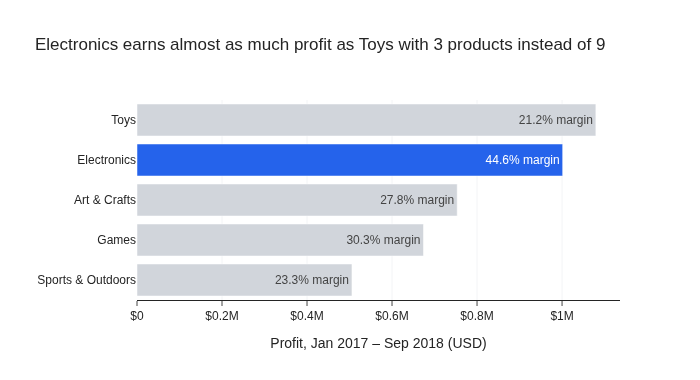

In [28]:
df_plot = df_category.sort_values('profit')

fig = px.bar(
    df_plot,
    x='profit',
    y='product_category',
    orientation='h',
    text=df_plot['margin_pct'].map('{:.1f}% margin'.format),
    labels={
        'profit': 'Profit, Jan 2017 – Sep 2018 (USD)',
        'product_category': '',
    },
    title='Electronics earns almost as much profit as Toys with 3 products instead of 9',
    height=380,
)
fig.update_traces(
    marker_color=[HIGHLIGHT if c == 'Electronics' else GRAY for c in df_plot['product_category']],
    textposition='inside',
    insidetextanchor='end',
)
fig.update_xaxes(tickprefix='$', showgrid=True, gridcolor='#F3F4F6')
fig.update_yaxes(ticks='', showline=False)
fig.show()

**Toys** is the most profitable category ($1.08M profit), but only narrowly ahead of **Electronics** ($1.00M), even though Toys brings in more than twice the revenue ($5.09M vs $2.25M). The difference is margin: Electronics earns **44.6%** on every dollar of revenue versus **21.2%** for Toys. Electronics has only 3 products, yet it generates 15.6% of revenue and 24.9% of profit. Sports & Outdoors is last on both profit ($0.51M) and has the second-thinnest margin (23.3%).

### 2. Is it the same across store locations?

`PARTITION BY store_location` restarts the window for each location type, so each category's profit share and rank are computed *within* its location.

In [29]:
query = '''
WITH location_category AS (
    SELECT
        st.store_location,
        p.product_category,
        SUM(s.units * (p.product_price - p.product_cost)) AS profit
    FROM sales AS s
    JOIN products AS p
        ON s.product_id = p.product_id
    JOIN stores AS st
        ON s.store_id = st.store_id
    GROUP BY st.store_location, p.product_category
)
SELECT
    store_location,
    product_category,
    ROUND(profit) AS profit,
    ROUND(100.0 * profit / SUM(profit) OVER (PARTITION BY store_location), 1) AS pct_of_location_profit,
    RANK() OVER (PARTITION BY store_location ORDER BY profit DESC) AS rank_in_location
FROM location_category
ORDER BY store_location, rank_in_location
'''
df_location_category = pd.read_sql(query, conn)
df_location_category.head(5)

,store_location,product_category,profit,pct_of_location_profit,rank_in_location
0,Airport,Electronics,108197.0,28.6,1
1,Airport,Toys,88250.0,23.3,2
2,Airport,Games,80768.0,21.4,3
3,Airport,Art & Crafts,61441.0,16.3,4
4,Airport,Sports & Outdoors,39393.0,10.4,5


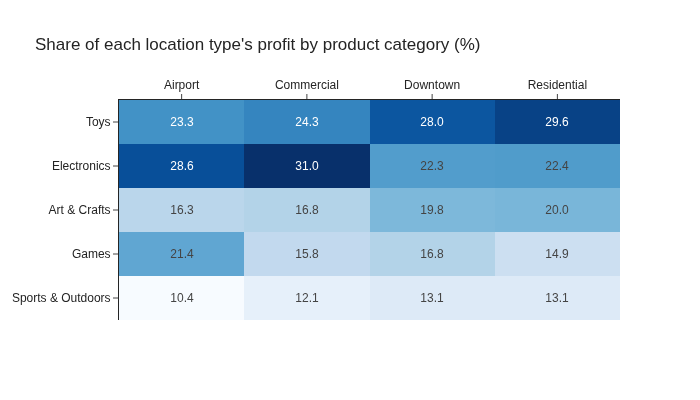

In [30]:
location_order = ['Airport', 'Commercial', 'Downtown', 'Residential']
category_order = df_category['product_category'].tolist()

df_share = df_location_category.pivot(
    index='product_category',
    columns='store_location',
    values='pct_of_location_profit'
).loc[category_order, location_order]

fig = px.imshow(
    df_share,
    text_auto='.1f',
    color_continuous_scale='Blues',
    aspect='auto',
    labels={'x': 'Store location', 'y': '', 'color': '% of profit'},
    title='Share of each location type\'s profit by product category (%)',
    height=400,
)
fig.update_xaxes(side='top', title='')
fig.update_layout(coloraxis_showscale=False)
fig.show()

The category ranking is broadly similar, with one swap at the top: **Electronics is the #1 profit category at Airport (28.6%) and Commercial (31.0%) stores**, while **Toys is #1 Downtown (28.0%) and in Residential stores (29.6%)**. Sports & Outdoors is last everywhere.

Location type is not the only thing that matters, though. The next query rolls profit up to the store level first (a CTE), then summarizes by location. It shows how much individual stores vary within each location type.

In [31]:
query = '''
WITH store_profit AS (
    SELECT
        st.store_id,
        st.store_location,
        SUM(s.units * (p.product_price - p.product_cost)) AS profit,
        SUM(CASE WHEN p.product_category = 'Electronics'
                 THEN s.units * (p.product_price - p.product_cost) ELSE 0 END) AS electronics_profit
    FROM sales AS s
    JOIN products AS p
        ON s.product_id = p.product_id
    JOIN stores AS st
        ON s.store_id = st.store_id
    GROUP BY st.store_id, st.store_location
)
SELECT
    store_location,
    COUNT(*) AS num_stores,
    ROUND(SUM(profit)) AS total_profit,
    ROUND(100.0 * SUM(profit) / SUM(SUM(profit)) OVER (), 1) AS pct_of_total_profit,
    ROUND(AVG(profit)) AS avg_profit_per_store,
    ROUND(100.0 * MIN(electronics_profit / profit), 1) AS min_store_electronics_pct,
    ROUND(100.0 * MAX(electronics_profit / profit), 1) AS max_store_electronics_pct
FROM store_profit
GROUP BY store_location
ORDER BY avg_profit_per_store DESC
'''
df_location = pd.read_sql(query, conn)
df_location

,store_location,num_stores,total_profit,pct_of_total_profit,avg_profit_per_store,min_store_electronics_pct,max_store_electronics_pct
0,Airport,3,378049.0,9.4,126016.0,22.8,31.0
1,Downtown,29,2248728.0,56.0,77542.0,11.9,37.4
2,Commercial,12,926864.0,23.1,77239.0,16.8,49.0
3,Residential,6,460388.0,11.5,76731.0,11.7,37.7


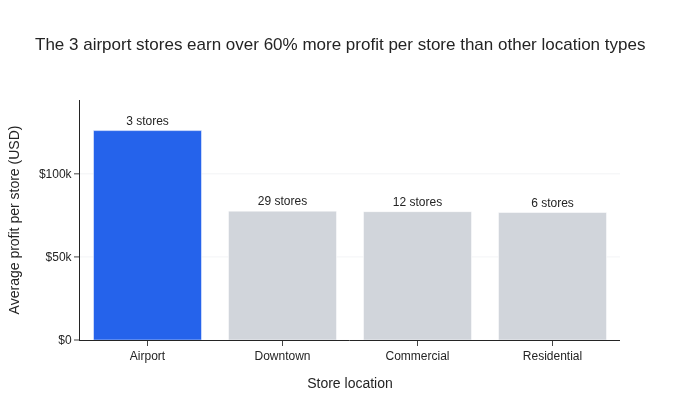

In [32]:
fig = px.bar(
    df_location,
    x='store_location',
    y='avg_profit_per_store',
    text=df_location['num_stores'].map('{} stores'.format),
    labels={
        'store_location': 'Store location',
        'avg_profit_per_store': 'Average profit per store (USD)',
    },
    title='The 3 airport stores earn over 60% more profit per store than other location types',
    height=420,
)
fig.update_traces(
    marker_color=[HIGHLIGHT if loc == 'Airport' else GRAY for loc in df_location['store_location']],
    textposition='outside',
)
fig.update_yaxes(tickprefix='$', showgrid=True, gridcolor='#F3F4F6')
fig.show()

- **Airport stores are the standouts on a per-store basis**: $126,016 average profit per store versus about $77,000 for Commercial, Downtown, and Residential stores, which are nearly identical. With only 3 airport stores, treat this as a strong hint rather than a law.
- **Downtown stores generate 56.0% of all profit** ($2.25M) simply because 29 of the 50 stores are downtown.
- The Electronics share swings widely *within* each location type (from 11.9% to 37.4% of profit across Downtown stores, and 16.8% to 49.0% across Commercial stores), so the location-level differences in category mix are modest compared with store-to-store variation.

### 3. Revenue leaders are not profit leaders

Ranking products by revenue and by profit side by side (two `RANK()` window functions) shows which best-sellers barely make money.

In [33]:
query = '''
WITH product_totals AS (
    SELECT
        p.product_name,
        p.product_category,
        p.product_price,
        p.product_cost,
        SUM(s.units) AS units_sold,
        SUM(s.units * p.product_price) AS revenue,
        SUM(s.units * (p.product_price - p.product_cost)) AS profit
    FROM sales AS s
    JOIN products AS p
        ON s.product_id = p.product_id
    GROUP BY p.product_id, p.product_name, p.product_category, p.product_price, p.product_cost
)
SELECT
    product_name,
    product_category,
    product_price,
    product_cost,
    units_sold,
    ROUND(revenue) AS revenue,
    ROUND(profit) AS profit,
    ROUND(100.0 * profit / revenue, 1) AS margin_pct,
    RANK() OVER (ORDER BY revenue DESC) AS revenue_rank,
    RANK() OVER (ORDER BY profit DESC) AS profit_rank,
    ROUND(100.0 * profit / SUM(profit) OVER (), 1) AS pct_of_total_profit
FROM product_totals
ORDER BY revenue_rank
'''
df_product = pd.read_sql(query, conn)
df_product.head(10)

,product_name,product_category,product_price,product_cost,units_sold,revenue,profit,margin_pct,revenue_rank,profit_rank,pct_of_total_profit
0,Lego Bricks,Toys,39.99,34.99,59737,2388883.0,298685.0,12.5,1,3,7.4
1,Colorbuds,Electronics,14.99,6.99,104368,1564476.0,834944.0,53.4,2,1,20.8
2,Magic Sand,Art & Crafts,15.99,13.99,60598,968962.0,121196.0,12.5,3,11,3.0
3,Action Figure,Toys,15.99,9.99,57958,926748.0,347748.0,37.5,4,2,8.7
4,Rubik's Cube,Games,19.99,17.99,45672,912983.0,91344.0,10.0,5,18,2.3
5,Deck Of Cards,Games,6.99,3.99,84034,587398.0,252102.0,42.9,6,4,6.3
6,Splash Balls,Sports & Outdoors,8.99,7.99,60248,541630.0,60248.0,11.1,7,20,1.5
7,Nerf Gun,Sports & Outdoors,19.99,14.99,26543,530595.0,132715.0,25.0,8,8,3.3
8,Animal Figures,Toys,12.99,9.99,39089,507766.0,117267.0,23.1,9,12,2.9
9,Dart Gun,Sports & Outdoors,15.99,11.99,31588,505092.0,126352.0,25.0,10,9,3.1


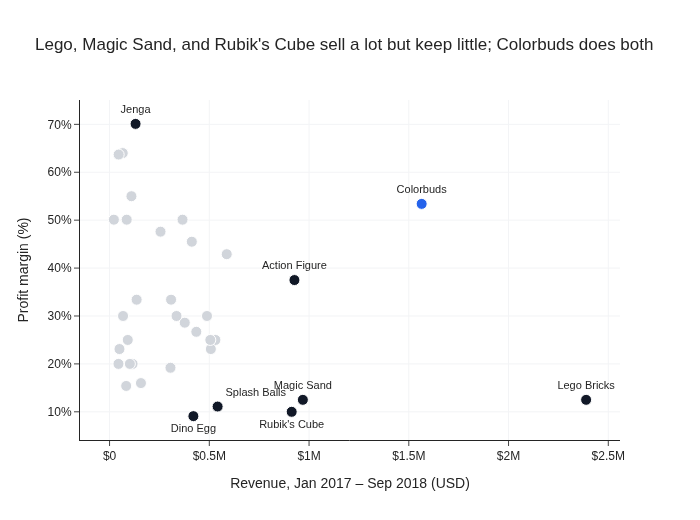

In [34]:
callouts = ['Colorbuds', 'Lego Bricks', 'Magic Sand', "Rubik's Cube", 'Action Figure', 'Splash Balls', 'Dino Egg', 'Jenga']

fig = px.scatter(
    df_product,
    x='revenue',
    y='margin_pct',
    hover_name='product_name',
    hover_data={'product_category': True, 'profit': ':$,.0f', 'revenue': ':$,.0f'},
    text=df_product['product_name'].where(df_product['product_name'].isin(callouts), ''),
    labels={
        'revenue': 'Revenue, Jan 2017 – Sep 2018 (USD)',
        'margin_pct': 'Profit margin (%)',
        'product_category': 'Category',
        'profit': 'Profit',
    },
    title='Lego, Magic Sand, and Rubik\'s Cube sell a lot but keep little; Colorbuds does both',
    height=520,
)
fig.update_traces(
    marker=dict(
        size=11,
        color=[HIGHLIGHT if n == 'Colorbuds' else (DARK if n in callouts else GRAY) for n in df_product['product_name']],
        line=dict(width=1, color='white'),
    ),
    textfont_size=11,
)
label_positions = {"Rubik's Cube": 'bottom center', 'Dino Egg': 'bottom center', 'Splash Balls': 'top right'}
fig.update_traces(textposition=[label_positions.get(n, 'top center') for n in df_product['product_name']])
fig.update_xaxes(tickprefix='$', showgrid=True, gridcolor='#F3F4F6')
fig.update_yaxes(ticksuffix='%', showgrid=True, gridcolor='#F3F4F6')
fig.show()

In [35]:
# thinnest and richest margins
pd.concat([
    df_product.nsmallest(5, 'margin_pct'),
    df_product.nlargest(3, 'margin_pct'),
])[['product_name', 'product_category', 'margin_pct', 'revenue_rank', 'profit_rank']]

,product_name,product_category,margin_pct,revenue_rank,profit_rank
12,Dino Egg,Toys,9.1,13,25
4,Rubik's Cube,Games,10.0,5,18
6,Splash Balls,Sports & Outdoors,11.1,7,20
0,Lego Bricks,Toys,12.5,1,3
2,Magic Sand,Art & Crafts,12.5,3,11
22,Jenga,Games,70.1,23,17
30,Mini Basketball Hoop,Sports & Outdoors,64.0,31,24
32,Playfoam,Art & Crafts,63.7,33,26


- **Colorbuds is the single most important product**: #2 in revenue ($1.56M) and #1 in profit ($834,944, **20.8% of all chain profit**) thanks to a 53.4% margin.
- **Lego Bricks is the #1 revenue product ($2.39M) but only #3 in profit**, with a 12.5% margin ($34.99 cost on a $39.99 price).
- **Magic Sand** (#3 revenue, #11 profit) and **Rubik's Cube** (#5 revenue, #18 profit) are similar high-volume, low-margin items. Dino Egg (9.1%), Rubik's Cube (10.0%), and Splash Balls (11.1%) have the thinnest margins of all.
- At the other end, small sellers like Jenga (70.1%), Mini Basketball Hoop (64.0%), and Playfoam (63.7%) have the richest margins.

### 4. Seasonal trends: monthly revenue, year-over-year growth, and day of week

SQLite stores dates as text, so `strftime()` extracts the year and month for grouping.

In [36]:
query = '''
SELECT
    strftime('%Y', s.date) AS year,
    CAST(strftime('%m', s.date) AS INTEGER) AS month,
    SUM(s.units) AS units_sold,
    ROUND(SUM(s.units * p.product_price)) AS revenue,
    ROUND(SUM(s.units * (p.product_price - p.product_cost))) AS profit,
    ROUND(100.0 * SUM(s.units * (p.product_price - p.product_cost)) / SUM(s.units * p.product_price), 1) AS margin_pct
FROM sales AS s
JOIN products AS p
    ON s.product_id = p.product_id
GROUP BY year, month
ORDER BY year, month
'''
df_monthly = pd.read_sql(query, conn)
df_monthly.head(3)

,year,month,units_sold,revenue,profit,margin_pct
0,2017,1,38009,542555.0,167126.0,30.8
1,2017,2,36935,541352.0,161861.0,29.9
2,2017,3,39981,589485.0,173992.0,29.5


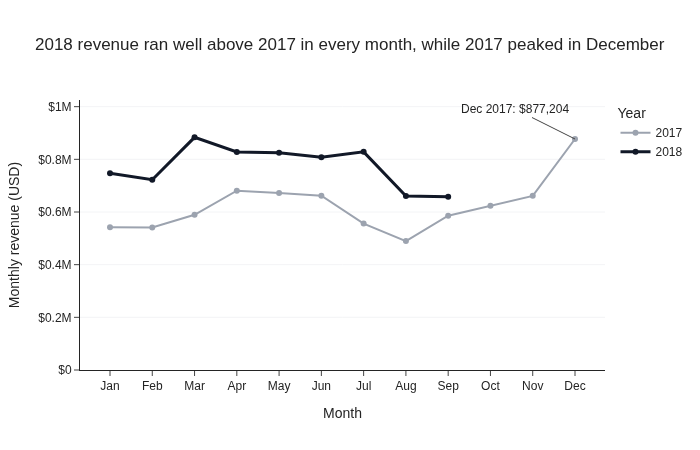

In [37]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_plot = df_monthly.assign(month_name=df_monthly['month'].map(lambda m: month_names[m - 1]))

fig = px.line(
    df_plot,
    x='month_name',
    y='revenue',
    color='year',
    markers=True,
    category_orders={'month_name': month_names},
    color_discrete_map={'2017': '#9CA3AF', '2018': DARK},
    labels={'month_name': 'Month', 'revenue': 'Monthly revenue (USD)', 'year': 'Year'},
    title='2018 revenue ran well above 2017 in every month, while 2017 peaked in December',
    height=450,
)
fig.for_each_trace(lambda t: t.update(line_width=3 if t.name == '2018' else 2))
dec_2017 = df_plot.query('year == "2017" and month == 12').iloc[0]
fig.add_annotation(
    x='Dec', y=dec_2017['revenue'],
    text=f"Dec 2017: ${dec_2017['revenue']:,.0f}",
    showarrow=True, arrowhead=0, ax=-60, ay=-30,
)
fig.update_yaxes(tickprefix='$', showgrid=True, gridcolor='#F3F4F6', rangemode='tozero')
fig.show()

Compare the same months across years with a **self-join**: the monthly CTE is joined to itself on month number, with one side filtered to 2017 and the other to 2018.

In [38]:
query = '''
WITH monthly AS (
    SELECT
        strftime('%Y', s.date) AS year,
        CAST(strftime('%m', s.date) AS INTEGER) AS month,
        SUM(s.units * p.product_price) AS revenue,
        SUM(s.units * (p.product_price - p.product_cost)) AS profit
    FROM sales AS s
    JOIN products AS p
        ON s.product_id = p.product_id
    GROUP BY year, month
)
SELECT
    m17.month,
    ROUND(m17.revenue) AS revenue_2017,
    ROUND(m18.revenue) AS revenue_2018,
    ROUND(100.0 * (m18.revenue / m17.revenue - 1), 1) AS revenue_yoy_pct,
    ROUND(100.0 * (m18.profit / m17.profit - 1), 1) AS profit_yoy_pct
FROM monthly AS m17
JOIN monthly AS m18
    ON m17.month = m18.month
WHERE m17.year = '2017'
  AND m18.year = '2018'
ORDER BY m17.month
'''
df_yoy = pd.read_sql(query, conn)
df_yoy

,month,revenue_2017,revenue_2018,revenue_yoy_pct,profit_yoy_pct
0,1,542555.0,747196.0,37.7,22.7
1,2,541352.0,722632.0,33.5,17.0
2,3,589485.0,883516.0,49.9,33.3
3,4,681073.0,827691.0,21.5,13.1
4,5,672370.0,825319.0,22.7,12.5
5,6,661980.0,808299.0,22.1,9.2
6,7,556034.0,828349.0,49.0,18.6
7,8,489423.0,660877.0,35.0,10.1
8,9,585844.0,658194.0,12.3,8.4


For the full January–September window, `LAG()` pulls the previous year's value onto the current row to compute growth.

In [39]:
query = '''
WITH jan_sep AS (
    SELECT
        strftime('%Y', s.date) AS year,
        SUM(s.units * p.product_price) AS revenue,
        SUM(s.units * (p.product_price - p.product_cost)) AS profit
    FROM sales AS s
    JOIN products AS p
        ON s.product_id = p.product_id
    WHERE strftime('%m', s.date) <= '09'
    GROUP BY year
)
SELECT
    year,
    ROUND(revenue) AS revenue_jan_sep,
    ROUND(profit) AS profit_jan_sep,
    ROUND(100.0 * profit / revenue, 1) AS margin_pct,
    ROUND(100.0 * (revenue / LAG(revenue) OVER (ORDER BY year) - 1), 1) AS revenue_growth_pct,
    ROUND(100.0 * (profit / LAG(profit) OVER (ORDER BY year) - 1), 1) AS profit_growth_pct
FROM jan_sep
ORDER BY year
'''
df_ytd = pd.read_sql(query, conn)
df_ytd

,year,revenue_jan_sep,profit_jan_sep,margin_pct,revenue_growth_pct,profit_growth_pct
0,2017,5320116.0,1572037.0,29.5,NaN,NaN
1,2018,6962074.0,1824242.0,26.2,30.9,16.0


- **Growth was strong but profit lagged revenue.** For the overlapping January–September window, revenue grew **30.9%** ($5.32M → $6.96M) but profit grew only **16.0%** ($1.57M → $1.82M). Profit growth trailed revenue growth in every single month (e.g., March: +49.9% revenue vs +33.3% profit; June: +22.1% vs +9.2%), and the margin fell from **29.5% to 26.2%**. Section 5 explains why.
- **Seasonality:** December 2017 was the best month of 2017 ($877,204), consistent with holiday gift buying. In both years, sales softened in late summer: August was the weakest month of 2017 ($489,423), and 2018 revenue dropped 20% from July ($828,349) to August ($660,877). Only one December is in the data, so the holiday peak cannot be confirmed across years.

**Day-of-week pattern.** A CTE first totals revenue per calendar day; the outer query then averages those daily totals by weekday (`strftime('%w')` returns 0 for Sunday through 6 for Saturday).

In [40]:
query = '''
WITH daily AS (
    SELECT
        s.date,
        CAST(strftime('%w', s.date) AS INTEGER) AS weekday_num,
        SUM(s.units * p.product_price) AS revenue
    FROM sales AS s
    JOIN products AS p
        ON s.product_id = p.product_id
    GROUP BY s.date
)
SELECT
    weekday_num,
    CASE weekday_num
        WHEN 0 THEN 'Sunday' WHEN 1 THEN 'Monday' WHEN 2 THEN 'Tuesday' WHEN 3 THEN 'Wednesday'
        WHEN 4 THEN 'Thursday' WHEN 5 THEN 'Friday' WHEN 6 THEN 'Saturday'
    END AS weekday,
    COUNT(*) AS num_days,
    ROUND(AVG(revenue)) AS avg_daily_revenue
FROM daily
GROUP BY weekday_num
ORDER BY (weekday_num + 6) % 7  -- Monday first
'''
df_weekday = pd.read_sql(query, conn)
df_weekday

,weekday_num,weekday,num_days,avg_daily_revenue
0,1,Monday,91,19228.0
1,2,Tuesday,91,16826.0
2,3,Wednesday,91,17994.0
3,4,Thursday,91,19034.0
4,5,Friday,91,23996.0
5,6,Saturday,91,30223.0
6,0,Sunday,92,31089.0


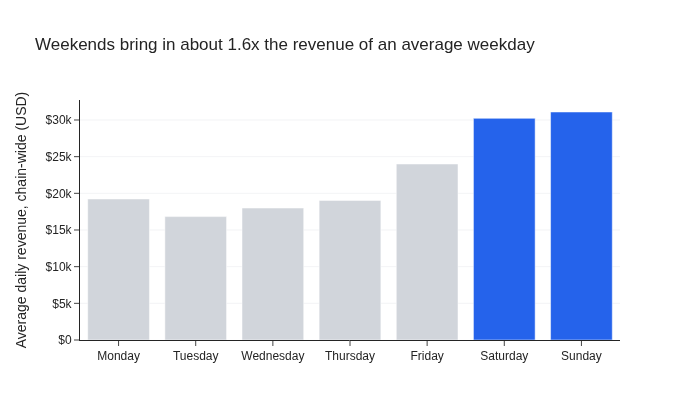

In [41]:
fig = px.bar(
    df_weekday,
    x='weekday',
    y='avg_daily_revenue',
    labels={'weekday': '', 'avg_daily_revenue': 'Average daily revenue, chain-wide (USD)'},
    title='Weekends bring in about 1.6x the revenue of an average weekday',
    height=420,
)
fig.update_traces(
    marker_color=[HIGHLIGHT if d in ('Saturday', 'Sunday') else GRAY for d in df_weekday['weekday']],
)
fig.update_yaxes(tickprefix='$', showgrid=True, gridcolor='#F3F4F6')
fig.show()

In [42]:
weekend_avg = df_weekday.query('weekday in ["Saturday", "Sunday"]')['avg_daily_revenue'].mean()
weekday_avg = df_weekday.query('weekday not in ["Saturday", "Sunday"]')['avg_daily_revenue'].mean()
print(f'Weekend average: ${weekend_avg:,.0f} | Weekday average: ${weekday_avg:,.0f} | Ratio: {weekend_avg / weekday_avg:.2f}x')

Weekend average: $30,656 | Weekday average: $19,416 | Ratio: 1.58x


Sunday ($31,089/day) and Saturday ($30,223/day) are the busiest days, about **1.58x** the average weekday ($19,416/day). Tuesday is the slowest day ($16,826), and Friday ($23,996) is already noticeably busier than Monday–Thursday. Staffing and replenishment should be weighted toward Friday through Sunday.

### 5. Why profit lagged revenue in 2018: a product-mix shift

Conditional aggregation (`SUM(CASE WHEN ...)`) puts 2017 and 2018 (January–September only) side by side for each product, so the change in revenue and profit can be attributed to individual products.

In [43]:
query = '''
WITH product_year AS (
    SELECT
        p.product_name,
        p.product_category,
        SUM(CASE WHEN strftime('%Y', s.date) = '2017' THEN s.units * p.product_price ELSE 0 END) AS revenue_2017,
        SUM(CASE WHEN strftime('%Y', s.date) = '2018' THEN s.units * p.product_price ELSE 0 END) AS revenue_2018,
        SUM(CASE WHEN strftime('%Y', s.date) = '2017' THEN s.units * (p.product_price - p.product_cost) ELSE 0 END) AS profit_2017,
        SUM(CASE WHEN strftime('%Y', s.date) = '2018' THEN s.units * (p.product_price - p.product_cost) ELSE 0 END) AS profit_2018
    FROM sales AS s
    JOIN products AS p
        ON s.product_id = p.product_id
    WHERE strftime('%m', s.date) <= '09'   -- Jan-Sep in both years
    GROUP BY p.product_id, p.product_name, p.product_category
)
SELECT
    product_name,
    product_category,
    ROUND(revenue_2017) AS revenue_2017,
    ROUND(revenue_2018) AS revenue_2018,
    ROUND(revenue_2018 - revenue_2017) AS revenue_change,
    ROUND(profit_2018 - profit_2017) AS profit_change,
    ROUND(100.0 * (profit_2017 + profit_2018) / (revenue_2017 + revenue_2018), 1) AS margin_pct
FROM product_year
ORDER BY revenue_change DESC
'''
df_product_yoy = pd.read_sql(query, conn)

# biggest gainers and decliners
pd.concat([df_product_yoy.head(5), df_product_yoy.tail(5)])

,product_name,product_category,revenue_2017,revenue_2018,revenue_change,profit_change,margin_pct
0,Magic Sand,Art & Crafts,3486.0,868849.0,865363.0,108238.0,12.5
1,Barrel O' Slime,Art & Crafts,21271.0,244316.0,223045.0,111802.0,50.1
2,Nerf Gun,Sports & Outdoors,131514.0,340230.0,208716.0,52205.0,25.0
3,Etch A Sketch,Art & Crafts,0.0,202071.0,202071.0,96270.0,47.6
4,Gamer Headphones,Electronics,47102.0,243316.0,196215.0,56088.0,28.6
30,Splash Balls,Sports & Outdoors,284507.0,208640.0,-75867.0,-8439.0,11.1
31,Kids Makeup Kit,Art & Crafts,257011.0,168656.0,-88356.0,-26520.0,30.0
32,Dart Gun,Sports & Outdoors,257871.0,163866.0,-94005.0,-23516.0,25.0
33,Action Figure,Toys,471641.0,334559.0,-137082.0,-51438.0,37.5
34,Colorbuds,Electronics,931434.0,437048.0,-494385.0,-263848.0,53.4


In [44]:
df_product_yoy[['revenue_change', 'profit_change']].sum()

revenue_change    1641961.0
profit_change      252205.0
dtype: float64

Two products dominate the story. **Magic Sand** (launched in July 2017) added **$865,363** of revenue but only **$108,238** of profit, because its margin is just 12.5%. Meanwhile **Colorbuds**, the most profitable product in the chain, *lost* **$494,385** of revenue and **$263,848** of profit. Together they explain why revenue grew by $1.64M but profit by only $252,205.

The monthly view makes the mechanics clear.

In [45]:
query = '''
SELECT
    strftime('%Y-%m-01', s.date) AS month,
    p.product_name,
    SUM(s.units) AS units_sold,
    ROUND(SUM(s.units * p.product_price)) AS revenue,
    ROUND(SUM(s.units * (p.product_price - p.product_cost))) AS profit
FROM sales AS s
JOIN products AS p
    ON s.product_id = p.product_id
WHERE p.product_name IN ('Colorbuds', 'Magic Sand')
GROUP BY month, p.product_name
ORDER BY month, p.product_name
'''
df_two_products = pd.read_sql(query, conn, parse_dates=['month'])
df_two_products.pivot(index='month', columns='product_name', values='units_sold').loc[
    ['2017-01-01', '2017-07-01', '2017-11-01', '2017-12-01', '2018-04-01', '2018-08-01', '2018-09-01']
]

product_name,Colorbuds,Magic Sand
month,,
2017-01-01,8110.0,NaN
2017-07-01,6511.0,5.0
2017-11-01,4284.0,1182.0
2017-12-01,4078.0,4613.0
2018-04-01,3369.0,7701.0
2018-08-01,3165.0,4092.0
2018-09-01,2594.0,4523.0


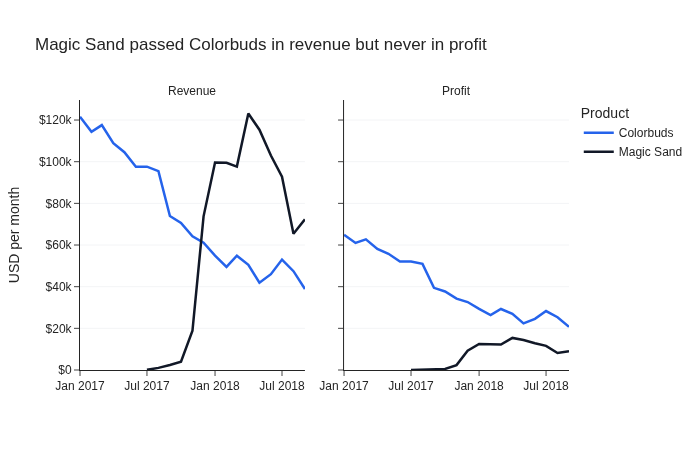

In [46]:
df_plot = df_two_products.melt(
    id_vars=['month', 'product_name'],
    value_vars=['revenue', 'profit'],
    var_name='metric',
    value_name='usd',
)
df_plot['metric'] = df_plot['metric'].str.title()

fig = px.line(
    df_plot,
    x='month',
    y='usd',
    color='product_name',
    facet_col='metric',
    color_discrete_map={'Colorbuds': HIGHLIGHT, 'Magic Sand': DARK},
    labels={'month': '', 'usd': 'USD per month', 'product_name': 'Product'},
    title='Magic Sand passed Colorbuds in revenue but never in profit',
    facet_col_spacing=0.08,
    height=450,
)
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
fig.update_xaxes(dtick='M6', tickformat='%b %Y')
fig.update_traces(line_width=2.5)
fig.update_yaxes(tickprefix='$', showgrid=True, gridcolor='#F3F4F6', rangemode='tozero')
fig.show()

- **Colorbuds units fell steadily**, from 8,110 in January 2017 to 2,594 in September 2018 (−68%). The decline is gradual and chain-wide rather than a sudden drop, and Colorbuds was in stock at every store in the inventory snapshot, which points to falling demand rather than supply problems.
- **Magic Sand took off in December 2017** (4,613 units, up from 1,182 in November) and has sold between 4,092 and 7,701 units every month since.
- Magic Sand passed Colorbuds in monthly revenue from December 2017 onward, yet its $2/unit profit means Colorbuds ($8/unit) still produced more profit in every month.

**Takeaway:** headline revenue growth hid a deteriorating mix. Maven Toys is replacing a high-margin hit with low-margin volume.

### 6. Store performance: top and bottom stores, and does store age matter?

`julianday()` turns ISO date strings into day numbers, so store age at the end of the data (2018-09-30) is a simple subtraction. `RANK() OVER (ORDER BY profit DESC)` ranks all 50 stores.

In [47]:
query = '''
WITH store_totals AS (
    SELECT
        s.store_id,
        SUM(s.units * p.product_price) AS revenue,
        SUM(s.units * (p.product_price - p.product_cost)) AS profit,
        SUM(CASE WHEN s.date BETWEEN '2017-01-01' AND '2017-09-30' THEN s.units * p.product_price END) AS revenue_2017_jan_sep,
        SUM(CASE WHEN s.date BETWEEN '2018-01-01' AND '2018-09-30' THEN s.units * p.product_price END) AS revenue_2018_jan_sep
    FROM sales AS s
    JOIN products AS p
        ON s.product_id = p.product_id
    GROUP BY s.store_id
)
SELECT
    RANK() OVER (ORDER BY t.profit DESC) AS profit_rank,
    st.store_name,
    st.store_location,
    st.store_open_date,
    ROUND((julianday('2018-09-30') - julianday(st.store_open_date)) / 365.25, 1) AS age_years,
    ROUND(t.revenue) AS revenue,
    ROUND(t.profit) AS profit,
    ROUND(100.0 * t.profit / t.revenue, 1) AS margin_pct,
    ROUND(100.0 * (t.revenue_2018_jan_sep / t.revenue_2017_jan_sep - 1), 1) AS revenue_growth_pct
FROM store_totals AS t
JOIN stores AS st
    ON t.store_id = st.store_id
ORDER BY profit_rank
'''
df_store = pd.read_sql(query, conn)
pd.concat([df_store.head(5), df_store.tail(5)])

,profit_rank,store_name,store_location,store_open_date,age_years,revenue,profit,margin_pct,revenue_growth_pct
0,1,Maven Toys Ciudad de Mexico 2,Airport,2012-05-04,6.4,554553.0,169856.0,30.6,23.4
1,2,Maven Toys Guadalajara 3,Airport,2011-10-20,6.9,449355.0,121571.0,27.1,31.6
2,3,Maven Toys Ciudad de Mexico 1,Downtown,2004-10-15,14.0,433556.0,111296.0,25.7,20.8
3,4,Maven Toys Monterrey 2,Downtown,2003-12-25,14.8,372999.0,106783.0,28.6,48.3
4,5,Maven Toys Toluca 1,Downtown,2007-12-09,10.8,411157.0,104612.0,25.4,47.9
45,46,Maven Toys Zacatecas 1,Downtown,2009-05-29,9.3,229983.0,59160.0,25.7,63.1
46,47,Maven Toys Campeche 2,Commercial,2010-09-15,8.0,206055.0,58091.0,28.2,45.5
47,48,Maven Toys Toluca 2,Commercial,2014-05-27,4.3,222364.0,58090.0,26.1,26.1
48,49,Maven Toys La Paz 1,Downtown,2001-05-31,17.3,210898.0,57407.0,27.2,42.4
49,50,Maven Toys Cuernavaca 1,Downtown,2005-04-19,13.4,221587.0,56811.0,25.6,37.0


In [48]:
rho_profit, p_profit = stats.spearmanr(df_store['age_years'], df_store['profit'])
rho_growth, p_growth = stats.spearmanr(df_store['age_years'], df_store['revenue_growth_pct'])
print(f'Store age vs profit:         Spearman rho = {rho_profit:.2f} (p = {p_profit:.2f})')
print(f'Store age vs revenue growth: Spearman rho = {rho_growth:.2f} (p = {p_growth:.2f})')

Store age vs profit:         Spearman rho = -0.04 (p = 0.76)
Store age vs revenue growth: Spearman rho = 0.06 (p = 0.68)


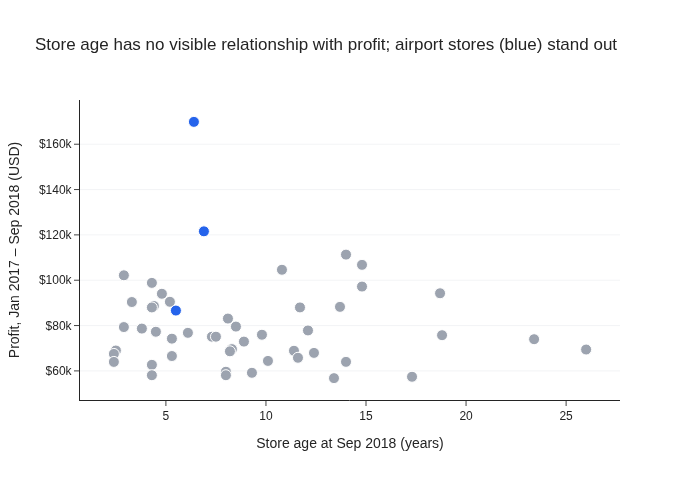

In [49]:
fig = px.scatter(
    df_store,
    x='age_years',
    y='profit',
    hover_name='store_name',
    hover_data={'store_location': True, 'profit': ':$,.0f'},
    labels={
        'age_years': 'Store age at Sep 2018 (years)',
        'profit': 'Profit, Jan 2017 – Sep 2018 (USD)',
        'store_location': 'Location',
    },
    title='Store age has no visible relationship with profit; airport stores (blue) stand out',
    height=480,
)
fig.update_traces(
    marker=dict(
        size=11,
        color=[HIGHLIGHT if loc == 'Airport' else '#9CA3AF' for loc in df_store['store_location']],
        line=dict(width=1, color='white'),
    )
)
fig.update_yaxes(tickprefix='$', showgrid=True, gridcolor='#F3F4F6')
fig.show()

- **The best store earns 3x the worst.** Maven Toys Ciudad de Mexico 2 (an airport store) leads with $169,856 in profit; Maven Toys Cuernavaca 1 (downtown) is last with $56,811. Two of the three airport stores are the top two stores overall.
- **Store age does not predict performance.** The rank correlation between store age and profit is essentially zero (Spearman ρ = −0.04, p = 0.76), and the same holds for 2018 revenue growth (ρ = 0.06, p = 0.68). The newest stores (about 2 years old) fall in the same profit range as stores more than 20 years old, so location and assortment matter more than maturity.

### 7. Are sales being lost to out-of-stock products?

**Caveat:** `inventory` is a *single snapshot* with no date. Because the last stockouts below all sold within days of 2018-09-30, the snapshot most likely reflects stock at the end of the sales data. A snapshot cannot show *how long* a product has been out of stock or how often stockouts happened in the past, so the numbers below measure **sales at risk per day while the item stays out of stock**, not realized lost sales.

The approach:

1. Measure each store × product's recent sales velocity: average units per day over the last 30 days of data (September 2018).
2. Rank products *within each store* by that velocity (`RANK() OVER (PARTITION BY store_id ...)`).
3. Join to the inventory snapshot and keep pairs with `stock_on_hand = 0`. Their recent velocity × price is the revenue at risk per day.

In [50]:
query = '''
WITH recent_velocity AS (
    SELECT
        store_id,
        product_id,
        SUM(units) / 30.0 AS daily_units
    FROM sales
    WHERE date >= '2018-09-01'
    GROUP BY store_id, product_id
),
ranked AS (
    SELECT
        *,
        RANK() OVER (PARTITION BY store_id ORDER BY daily_units DESC) AS velocity_rank_in_store
    FROM recent_velocity
),
last_sale AS (
    SELECT store_id, product_id, MAX(date) AS last_sale_date
    FROM sales
    GROUP BY store_id, product_id
)
SELECT
    st.store_name,
    st.store_location,
    p.product_name,
    p.product_category,
    i.stock_on_hand,
    l.last_sale_date,
    ROUND(r.daily_units, 2) AS daily_units,
    r.velocity_rank_in_store,
    ROUND(r.daily_units * p.product_price, 2) AS daily_revenue_at_risk,
    ROUND(r.daily_units * (p.product_price - p.product_cost), 2) AS daily_profit_at_risk
FROM inventory AS i
JOIN ranked AS r
    ON i.store_id = r.store_id AND i.product_id = r.product_id
JOIN last_sale AS l
    ON i.store_id = l.store_id AND i.product_id = l.product_id
JOIN products AS p
    ON i.product_id = p.product_id
JOIN stores AS st
    ON i.store_id = st.store_id
WHERE i.stock_on_hand = 0
ORDER BY daily_revenue_at_risk DESC
'''
df_out_of_stock = pd.read_sql(query, conn)
print(f'Out-of-stock store x product pairs: {df_out_of_stock.shape[0]}')
print(f"Of which top-10 sellers at their store: {(df_out_of_stock['velocity_rank_in_store'] <= 10).sum()}")
print(f"Last sale date range: {df_out_of_stock['last_sale_date'].min()} to {df_out_of_stock['last_sale_date'].max()}")
df_out_of_stock.head(10)

Out-of-stock store x product pairs: 77
Of which top-10 sellers at their store: 35
Last sale date range: 2018-09-20 to 2018-09-30


,store_name,store_location,product_name,product_category,stock_on_hand,last_sale_date,daily_units,velocity_rank_in_store,daily_revenue_at_risk,daily_profit_at_risk
0,Maven Toys Culiacan 1,Downtown,Animal Figures,Toys,0,2018-09-30,7.50,1,97.42,22.50
1,Maven Toys Hermosillo 2,Downtown,Playfoam,Art & Crafts,0,2018-09-28,4.43,1,48.72,31.03
2,Maven Toys Aguascalientes 1,Downtown,Mini Ping Pong Set,Sports & Outdoors,0,2018-09-30,4.70,1,46.95,14.10
3,Maven Toys Monterrey 3,Airport,Gamer Headphones,Electronics,0,2018-09-30,2.17,7,45.48,13.00
4,Maven Toys Guanajuato 2,Commercial,Playfoam,Art & Crafts,0,2018-09-30,4.03,3,44.33,28.23
5,Maven Toys Mexicali 2,Downtown,Action Figure,Toys,0,2018-09-30,2.60,6,41.57,15.60
6,Maven Toys Pachuca 1,Downtown,Dino Egg,Toys,0,2018-09-30,3.73,2,41.03,3.73
7,Maven Toys Toluca 2,Commercial,Playfoam,Art & Crafts,0,2018-09-23,3.70,3,40.66,25.90
8,Maven Toys Guadalajara 1,Residential,Toy Robot,Electronics,0,2018-09-26,1.50,11,38.98,7.50
9,Maven Toys Ciudad de Mexico 4,Commercial,Dino Egg,Toys,0,2018-09-30,3.53,1,38.83,3.53


Now roll the same logic up to location type and compare it with each location's normal daily revenue. `n_active_pairs` counts store × product pairs that sold anything in September, as the base for an out-of-stock rate.

In [51]:
query = '''
WITH recent_velocity AS (
    SELECT store_id, product_id, SUM(units) / 30.0 AS daily_units
    FROM sales
    WHERE date >= '2018-09-01'
    GROUP BY store_id, product_id
),
pair_status AS (
    SELECT
        st.store_location,
        r.daily_units,
        r.daily_units * p.product_price AS daily_revenue,
        -- explicit zero-stock rows only; pairs with no inventory record are examined separately below
        CASE WHEN i.stock_on_hand = 0 THEN 1 ELSE 0 END AS is_out_of_stock
    FROM recent_velocity AS r
    JOIN products AS p
        ON r.product_id = p.product_id
    JOIN stores AS st
        ON r.store_id = st.store_id
    LEFT JOIN inventory AS i
        ON r.store_id = i.store_id AND r.product_id = i.product_id
)
SELECT
    store_location,
    COUNT(*) AS n_active_pairs,
    SUM(is_out_of_stock) AS n_out_of_stock,
    ROUND(100.0 * SUM(is_out_of_stock) / COUNT(*), 1) AS pct_pairs_out_of_stock,
    ROUND(SUM(daily_revenue)) AS daily_revenue,
    ROUND(SUM(CASE WHEN is_out_of_stock THEN daily_revenue ELSE 0 END)) AS daily_revenue_at_risk,
    ROUND(100.0 * SUM(CASE WHEN is_out_of_stock THEN daily_revenue ELSE 0 END) / SUM(daily_revenue), 1) AS pct_revenue_at_risk
FROM pair_status
GROUP BY store_location
ORDER BY pct_revenue_at_risk DESC
'''
df_oos_location = pd.read_sql(query, conn)
df_oos_location

,store_location,n_active_pairs,n_out_of_stock,pct_pairs_out_of_stock,daily_revenue,daily_revenue_at_risk,pct_revenue_at_risk
0,Residential,148,14,9.5,2675.0,189.0,7.1
1,Downtown,718,46,6.4,12937.0,902.0,7.0
2,Commercial,293,15,5.1,4651.0,225.0,4.8
3,Airport,73,2,2.7,1676.0,55.0,3.3


In [52]:
chain_at_risk = df_oos_location['daily_revenue_at_risk'].sum()
chain_daily_revenue = df_oos_location['daily_revenue'].sum()
print(f'Chain-wide: ${chain_at_risk:,.0f}/day at risk out of ${chain_daily_revenue:,.0f}/day '
      f'({chain_at_risk / chain_daily_revenue:.1%})')

Chain-wide: $1,371/day at risk out of $21,939/day (6.2%)


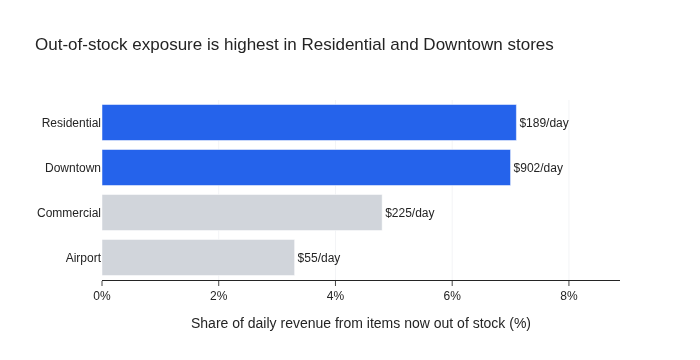

In [53]:
fig = px.bar(
    df_oos_location.sort_values('pct_revenue_at_risk'),
    x='pct_revenue_at_risk',
    y='store_location',
    orientation='h',
    text=df_oos_location.sort_values('pct_revenue_at_risk')['daily_revenue_at_risk'].map('${:,.0f}/day'.format),
    labels={
        'pct_revenue_at_risk': 'Share of daily revenue from items now out of stock (%)',
        'store_location': '',
    },
    title='Out-of-stock exposure is highest in Residential and Downtown stores',
    height=360,
)
fig.update_traces(
    marker_color=[HIGHLIGHT if loc in ('Residential', 'Downtown') else GRAY
                  for loc in df_oos_location.sort_values('pct_revenue_at_risk')['store_location']],
    textposition='outside',
)
fig.update_xaxes(
    ticksuffix='%', showgrid=True, gridcolor='#F3F4F6',
    range=[0, df_oos_location['pct_revenue_at_risk'].max() * 1.25],
)
fig.update_yaxes(ticks='', showline=False)
fig.show()

In [54]:
df_oos_product = df_out_of_stock.groupby(['product_name', 'product_category'], as_index=False).agg({
    'store_name': 'count',
    'daily_revenue_at_risk': 'sum',
    'daily_profit_at_risk': 'sum',
}).rename(columns={
    'store_name': 'num_stores_out_of_stock',
}).sort_values('daily_revenue_at_risk', ascending=False)

df_oos_product.head(8).round(2)

,product_name,product_category,num_stores_out_of_stock,daily_revenue_at_risk,daily_profit_at_risk
14,Playfoam,Art & Crafts,13,335.94,213.96
12,Mini Ping Pong Set,Sports & Outdoors,6,167.82,50.40
5,Dino Egg,Toys,6,142.51,12.96
0,Action Figure,Toys,5,126.31,47.40
1,Animal Figures,Toys,3,122.54,28.30
10,Hot Wheels 5-Pack,Toys,12,99.03,33.05
8,Gamer Headphones,Electronics,2,71.37,20.40
6,Etch A Sketch,Art & Crafts,7,69.28,33.00


- **77 store × product pairs are out of stock**, and **35 of them are among their store's 10 fastest sellers**. Every one of them sold within the 10 days before the snapshot (last sales between 2018-09-20 and 2018-09-30), so these are fresh stockouts of items that are actively selling.
- Across the chain, items now at zero stock had been bringing in about **$1,371 per day** in revenue, roughly 6% of September's daily revenue. That money is at risk every day they stay empty.
- **Residential (7.1% of daily revenue, 9.5% of active pairs) and Downtown (7.0%) stores are most exposed; Airport stores are least (3.3%).** The airport stores, which are the most profitable per store, also appear to be the best stocked.
- **Toys and Art & Crafts account for most of the exposure.** **Playfoam**, launched in mid-August 2018, is already out of stock at 13 stores and has the most revenue at risk ($336/day), a sign that replenishment has not kept up with a new product's demand. **Hot Wheels 5-Pack** is out at 12 stores, and Mini Ping Pong Set and Dino Egg at 6 each.

**What about store × product pairs with no inventory record at all?** An *anti-join* (`LEFT JOIN ... WHERE i.store_id IS NULL`) finds pairs that have sales history but no row in the snapshot.

In [55]:
query = '''
WITH sold_pairs AS (
    SELECT store_id, product_id, MAX(date) AS last_sale_date, SUM(units) AS units_sold
    FROM sales
    GROUP BY store_id, product_id
)
SELECT
    p.product_name,
    COUNT(*) AS num_stores_without_record,
    MIN(sp.last_sale_date) AS earliest_last_sale,
    MAX(sp.last_sale_date) AS latest_last_sale
FROM sold_pairs AS sp
LEFT JOIN inventory AS i
    ON sp.store_id = i.store_id AND sp.product_id = i.product_id
JOIN products AS p
    ON sp.product_id = p.product_id
WHERE i.store_id IS NULL
GROUP BY p.product_name
ORDER BY num_stores_without_record DESC
'''
df_missing_inventory = pd.read_sql(query, conn)
df_missing_inventory

,product_name,num_stores_without_record,earliest_last_sale,latest_last_sale
0,Jenga,24,2018-05-26,2018-09-13
1,Mini Basketball Hoop,5,2017-02-06,2017-12-16
2,Classic Dominoes,4,2017-05-20,2018-01-06
3,Uno Card Game,3,2017-05-31,2018-02-07
4,Chutes & Ladders,2,2017-10-28,2018-02-22
5,Plush Pony,1,2018-03-16,2018-03-16
6,Mr. Potatohead,1,2018-03-24,2018-03-24
7,Monopoly,1,2018-01-27,2018-01-27


In [56]:
query = '''
WITH jenga_status AS (
    SELECT
        st.store_id,
        CASE WHEN i.stock_on_hand > 0 THEN 'stock_in_snapshot' ELSE 'no_stock_or_no_record' END AS status
    FROM stores AS st
    LEFT JOIN inventory AS i
        ON st.store_id = i.store_id AND i.product_id = 16  -- Jenga
)
SELECT
    strftime('%Y-%m', s.date) AS month,
    j.status,
    SUM(s.units) AS units_sold
FROM sales AS s
JOIN jenga_status AS j
    ON s.store_id = j.store_id
WHERE s.product_id = 16
  AND s.date >= '2018-04-01'
GROUP BY month, j.status
'''
pd.read_sql(query, conn).pivot(index='month', columns='status', values='units_sold')

status,no_stock_or_no_record,stock_in_snapshot
month,,
2018-04,372,322
2018-05,362,320
2018-06,387,377
2018-07,257,252
2018-08,93,96
2018-09,34,76


The 17 non-Jenga missing pairs are small assortment items (e.g., Mini Basketball Hoop, Classic Dominoes, Uno Card Game) that those stores last sold between February 2017 and March 2018. But **Jenga is missing at 24 stores**, all of which sold it regularly until sometime between May and September 2018. Jenga has the best margin in the chain (70.1%), so this looks like a classic lost-sales story. The data does not fully support that reading, though: Jenga sales also collapsed at the stores that *still hold Jenga stock* (from 377 units in June to 76 in September), and several of those stores show stock on hand with no Jenga sales for months. Whether the collapse is caused by supply, demand, or a delisting cannot be settled without dated inventory history. That is a good discussion point for students.

### 8. How much money is tied up in inventory, and how long will it last?

Inventory value at cost is `stock_on_hand × product_cost`. **Days of supply** = stock on hand ÷ recent daily unit sales (September 2018 velocity, as above). It answers "if nothing is restocked, how many days until this runs out?" 

In [57]:
query = '''
WITH recent_velocity AS (
    SELECT store_id, product_id, SUM(units) / 30.0 AS daily_units
    FROM sales
    WHERE date >= '2018-09-01'
    GROUP BY store_id, product_id
)
SELECT
    SUM(i.stock_on_hand) AS units_on_hand,
    ROUND(SUM(i.stock_on_hand * p.product_cost)) AS inventory_value_at_cost,
    ROUND(SUM(i.stock_on_hand * p.product_price)) AS inventory_value_at_retail,
    ROUND(SUM(COALESCE(r.daily_units, 0)), 1) AS daily_units_sold,
    ROUND(SUM(i.stock_on_hand) / SUM(COALESCE(r.daily_units, 0)), 1) AS days_of_supply
FROM inventory AS i
JOIN products AS p
    ON i.product_id = p.product_id
LEFT JOIN recent_velocity AS r
    ON i.store_id = r.store_id AND i.product_id = r.product_id
'''
pd.read_sql(query, conn)

,units_on_hand,inventory_value_at_cost,inventory_value_at_retail,daily_units_sold,days_of_supply
0,29742,300210.0,410241.0,1737.4,17.1


In [58]:
query = '''
WITH recent_velocity AS (
    SELECT store_id, product_id, SUM(units) / 30.0 AS daily_units
    FROM sales
    WHERE date >= '2018-09-01'
    GROUP BY store_id, product_id
)
SELECT
    p.product_category,
    SUM(i.stock_on_hand) AS units_on_hand,
    ROUND(SUM(i.stock_on_hand * p.product_cost)) AS inventory_value_at_cost,
    ROUND(100.0 * SUM(i.stock_on_hand * p.product_cost) / SUM(SUM(i.stock_on_hand * p.product_cost)) OVER (), 1) AS pct_of_inventory_value,
    ROUND(SUM(i.stock_on_hand) / SUM(COALESCE(r.daily_units, 0)), 1) AS days_of_supply
FROM inventory AS i
JOIN products AS p
    ON i.product_id = p.product_id
LEFT JOIN recent_velocity AS r
    ON i.store_id = r.store_id AND i.product_id = r.product_id
GROUP BY p.product_category
ORDER BY inventory_value_at_cost DESC
'''
df_inventory_category = pd.read_sql(query, conn)
df_inventory_category

,product_category,units_on_hand,inventory_value_at_cost,pct_of_inventory_value,days_of_supply
0,Toys,7553,99861.0,33.3,18.5
1,Art & Crafts,8635,65076.0,21.7,12.2
2,Sports & Outdoors,4981,53077.0,17.7,18.1
3,Games,6155,51489.0,17.2,29.4
4,Electronics,2418,30706.0,10.2,17.8


In [59]:
query = '''
WITH recent_velocity AS (
    SELECT store_id, product_id, SUM(units) / 30.0 AS daily_units
    FROM sales
    WHERE date >= '2018-09-01'
    GROUP BY store_id, product_id
)
SELECT
    p.product_name,
    p.product_category,
    SUM(i.stock_on_hand) AS units_on_hand,
    ROUND(SUM(i.stock_on_hand * p.product_cost)) AS inventory_value_at_cost,
    ROUND(SUM(COALESCE(r.daily_units, 0)), 1) AS daily_units_sold,
    ROUND(SUM(i.stock_on_hand) / SUM(COALESCE(r.daily_units, 0)), 1) AS days_of_supply
FROM inventory AS i
JOIN products AS p
    ON i.product_id = p.product_id
LEFT JOIN recent_velocity AS r
    ON i.store_id = r.store_id AND i.product_id = r.product_id
GROUP BY p.product_id, p.product_name, p.product_category
ORDER BY days_of_supply DESC
'''
df_inventory_product = pd.read_sql(query, conn)

# longest and shortest days of supply
pd.concat([df_inventory_product.head(5), df_inventory_product.tail(4)])

,product_name,product_category,units_on_hand,inventory_value_at_cost,daily_units_sold,days_of_supply
0,Mini Basketball Hoop,Sports & Outdoors,234,2104.0,2.3,101.7
1,Plush Pony,Toys,497,4468.0,7.1,70.0
2,Jenga,Games,181,541.0,2.7,67.9
3,Supersoaker Water Gun,Sports & Outdoors,513,6151.0,8.4,61.1
4,Teddy Bear,Toys,483,5308.0,8.3,58.4
31,Hot Wheels 5-Pack,Toys,376,1500.0,47.9,7.8
32,Dino Egg,Toys,649,6484.0,86.3,7.5
33,Barrel O' Slime,Art & Crafts,1282,2551.0,175.1,7.3
34,Playfoam,Art & Crafts,357,1424.0,94.9,3.8


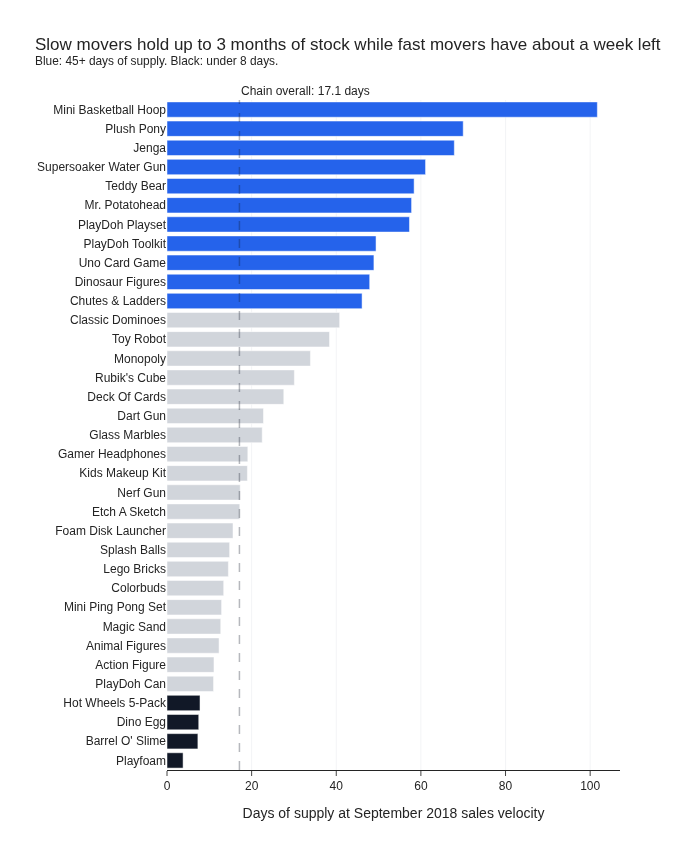

In [60]:
chain_days_of_supply = df_inventory_product['units_on_hand'].sum() / df_inventory_product['daily_units_sold'].sum()
df_plot = df_inventory_product.sort_values('days_of_supply')

fig = px.bar(
    df_plot,
    x='days_of_supply',
    y='product_name',
    orientation='h',
    hover_data={'inventory_value_at_cost': ':$,.0f', 'units_on_hand': True},
    labels={
        'days_of_supply': 'Days of supply at September 2018 sales velocity',
        'product_name': '',
        'inventory_value_at_cost': 'Inventory value at cost',
        'units_on_hand': 'Units on hand',
    },
    title='Slow movers hold up to 3 months of stock while fast movers have about a week left'
          '<br><sup>Blue: 45+ days of supply. Black: under 8 days.</sup>',
    height=850,
)
fig.update_traces(
    marker_color=[HIGHLIGHT if d >= 45 else (DARK if d < 8 else GRAY) for d in df_plot['days_of_supply']],
)
fig.add_vline(x=chain_days_of_supply, line_dash='dash', line_width=1.5, line_color=DARK, layer='above')
fig.add_annotation(
    x=chain_days_of_supply, y=1, yref='paper', yanchor='bottom', xanchor='left',
    text=f'Chain overall: {chain_days_of_supply:.1f} days', showarrow=False,
)
fig.update_xaxes(showgrid=True, gridcolor='#F3F4F6')
fig.update_yaxes(ticks='', showline=False)
fig.show()

Days of supply also varies by store. A store with a high number is carrying more stock than its sales justify.

In [61]:
query = '''
WITH recent_velocity AS (
    SELECT store_id, product_id, SUM(units) / 30.0 AS daily_units
    FROM sales
    WHERE date >= '2018-09-01'
    GROUP BY store_id, product_id
)
SELECT
    st.store_name,
    st.store_location,
    ROUND(SUM(i.stock_on_hand * p.product_cost)) AS inventory_value_at_cost,
    ROUND(SUM(i.stock_on_hand) / SUM(COALESCE(r.daily_units, 0)), 1) AS days_of_supply
FROM inventory AS i
JOIN products AS p
    ON i.product_id = p.product_id
JOIN stores AS st
    ON i.store_id = st.store_id
LEFT JOIN recent_velocity AS r
    ON i.store_id = r.store_id AND i.product_id = r.product_id
GROUP BY st.store_id, st.store_name, st.store_location
ORDER BY days_of_supply DESC
'''
df_inventory_store = pd.read_sql(query, conn)
df_inventory_store['days_of_supply'].describe().round(1)

count    50.0
mean     18.0
std       5.4
min       8.5
25%      14.3
50%      17.2
75%      20.4
max      36.3
Name: days_of_supply, dtype: float64

In [62]:
pd.concat([df_inventory_store.head(3), df_inventory_store.tail(3)])

,store_name,store_location,inventory_value_at_cost,days_of_supply
0,Maven Toys Campeche 1,Downtown,6515.0,36.3
1,Maven Toys Hermosillo 3,Commercial,7666.0,29.7
2,Maven Toys Morelia 1,Downtown,5413.0,29.5
47,Maven Toys Monterrey 2,Downtown,5960.0,9.9
48,Maven Toys Saltillo 1,Downtown,4270.0,9.9
49,Maven Toys Guanajuato 1,Downtown,3308.0,8.5


Finally, **dead stock**: store × product pairs with stock on hand but *no sales at all* in the last quarter of the data (July–September 2018).

In [63]:
query = '''
WITH recent_sales AS (
    SELECT DISTINCT store_id, product_id
    FROM sales
    WHERE date >= '2018-07-01'
)
SELECT
    p.product_name,
    COUNT(*) AS num_stores,
    SUM(i.stock_on_hand) AS units_on_hand,
    ROUND(SUM(i.stock_on_hand * p.product_cost)) AS inventory_value_at_cost
FROM inventory AS i
JOIN products AS p
    ON i.product_id = p.product_id
LEFT JOIN recent_sales AS rs
    ON i.store_id = rs.store_id AND i.product_id = rs.product_id
WHERE i.stock_on_hand > 0
  AND rs.store_id IS NULL
GROUP BY p.product_id, p.product_name
ORDER BY inventory_value_at_cost DESC
'''
df_dead_stock = pd.read_sql(query, conn)
print(f"Dead-stock pairs: {df_dead_stock['num_stores'].sum()} | units: {df_dead_stock['units_on_hand'].sum():,} | value at cost: ${df_dead_stock['inventory_value_at_cost'].sum():,.0f}")
df_dead_stock.head(5)

Dead-stock pairs: 89 | units: 1,319 | value at cost: $16,341


,product_name,num_stores,units_on_hand,inventory_value_at_cost
0,PlayDoh Playset,12,157,3295.0
1,Dinosaur Figures,4,225,2473.0
2,Toy Robot,6,110,2309.0
3,Supersoaker Water Gun,12,137,1643.0
4,Kids Makeup Kit,4,95,1329.0


- **About $300K is tied up in inventory at cost** ($410K at retail): 29,742 units across the 50 stores. At September's sales pace, that is **17.1 days of supply** chain-wide. The snapshot does not tell us lead times or reorder schedules, so we cannot judge whether 17 days is lean or generous, only where it is unbalanced.
- **Toys holds the most capital** ($99,861, 33.3% of the total). **Games turns slowest** (29.4 days of supply), while Art & Crafts turns fastest (12.2 days).
- **The imbalance is at the product level.** Slow movers such as Mini Basketball Hoop (101.7 days), Plush Pony (70.0), Jenga (67.9), Supersoaker Water Gun (61.1), and Teddy Bear (58.4) carry two months of stock or more, while the fast movers that are stocking out (Playfoam 3.8 days, Barrel O' Slime 7.3, Dino Egg 7.5, Hot Wheels 5-Pack 7.8) have about a week left. This is the same pattern as Section 7 seen from the other side.
- **Stores range from 8.5 to 36.3 days of supply** (median 17.2), so some stores could shift capital from slow movers into fast movers.
- **Dead stock is small:** 89 store × product pairs, 1,319 units, and about $16.3K at cost (about 5% of inventory value) have not sold once since July 1, led by PlayDoh Playset, Dinosaur Figures, and Toy Robot.

## Key Findings

- **Electronics is the profit engine per dollar of sales.** With only 3 products, it generates 15.6% of revenue but 24.9% of profit (44.6% margin), nearly matching Toys ($1.00M vs $1.08M profit) on less than half the revenue. It is the #1 profit category at Airport and Commercial stores; Toys is #1 Downtown and in Residential stores.
- **Revenue grew 30.9% (Jan–Sep 2018 vs 2017), but profit grew only 16.0%**, and the margin slipped from 29.5% to 26.2%. The cause is product mix: low-margin Magic Sand (12.5%) added $865K of revenue but only $108K of profit, while Colorbuds, the most profitable product (20.8% of all profit), lost $494K of revenue as its unit sales fell 68%.
- **Sales are seasonal and weekly.** December 2017 was 2017's peak month ($877K), sales soften in August, and weekends bring in about 1.58x the revenue of a weekday.
- **Airport stores are the most profitable per store** ($126K vs ~$77K for every other location type). Store age has no relationship with profit (Spearman ρ = −0.04).
- **Stockouts are concentrated in fast movers and in Residential/Downtown stores.** 77 store × product pairs are at zero stock (35 of them among their store's top-10 sellers), putting about $1,371/day of revenue at risk. Exposure is 7.1% of daily revenue in Residential stores versus 3.3% in airport stores, and the newly launched Playfoam is out at 13 stores.
- **About $300K (at cost) is tied up in inventory, or 17.1 days of supply**, but unevenly: slow movers hold two months of stock or more while the products that are stocking out have about a week left.

## Case Study Potential

**Verdict: Strong.** The dataset is clean, realistic, and naturally relational (four tables with clear keys), so it teaches database design and SQL as well as analysis. More importantly, the obvious answers are incomplete in instructive ways. "Toys is the top category" hides Electronics' margin advantage, "revenue grew 31%" hides a margin squeeze driven by product mix, and "stock is zero" needs careful reasoning because inventory is a single snapshot.

**Suggested framing.** Students act as a new analyst at Maven Toys preparing for a meeting with the head of merchandising. The decision: *where should the chain put its next dollar of inventory and shelf space?* Should it chase revenue (Lego, Magic Sand) or protect margin (Colorbuds, Electronics)? Which stores and products need replenishment fixes before the holiday season?

**Analytics skills exercised:** relational schema design (primary/foreign keys, constraints, indexes), data cleaning and validation with assertions, SQL joins (inner, left, self-join, anti-join), `GROUP BY` with conditional aggregation, CTEs, window functions (`RANK`, `SUM() OVER`, `PARTITION BY`), date functions, time-series comparison (YoY), and inventory metrics (days of supply, dead stock).

**Candidate student questions:**
1. Build the database with keys and constraints. What would `PRAGMA foreign_key_check` catch that pandas would not?
2. Which product category drives the most profit, and does the answer change if you rank by revenue, by margin, or within each store location?
3. Revenue grew 31% in Jan–Sep 2018, but profit grew only 16%. Decompose the gap by product. Which two products explain most of it?
4. Using recent sales velocity, estimate the daily revenue at risk from out-of-stock items by location. What assumptions does this estimate depend on, and how would dated inventory history change your answer?
5. Recommend how to rebalance about $300K of inventory across products and stores. Which items would you reorder first, and which would you mark down?

**Data limitations:** the data is fictitious. Inventory is a single undated snapshot (no stockout history, lead times, or reorder points). Each product has one fixed price and cost (no discounts, promotions, returns, or cost changes). There are no store sizes, foot traffic, or operating costs, so "profit" is gross profit on merchandise only. The data covers 21 months with only one holiday season, and there are just 3 airport stores.

In [64]:
conn.close()